### Import Prices


In [1]:
from pathlib import Path
import os
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("ENTSOE_API_KEY")
print("clé =", api_key[:5], "...")


PROJECT_ROOT = Path.cwd()  # if notebook is in project root, otherwise adjust
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

#API key
load_dotenv(PROJECT_ROOT / ".env")
API_KEY = os.getenv("ENTSOE_API_KEY")
if not API_KEY:
    raise RuntimeError("API key is required")


clé = d1f8b ...


In [2]:
import pandas as pd
from entsoe import EntsoePandasClient

client = EntsoePandasClient(api_key=API_KEY)

ZONE = "DE_LU"

start = pd.Timestamp("2023-01-01", tz="UTC")
end_exclusive = pd.Timestamp("2025-12-31", tz="UTC")  

prices = client.query_day_ahead_prices(ZONE, start=start, end=end_exclusive)

prices_df = prices.to_frame(name="price_eur_mwh")
prices_df.index.name = "datetime"
prices_df = prices_df.tz_convert("UTC")
prices_df.head()  


,price_eur_mwh
datetime,
2023-01-01 00:00:00+00:00,-1.07
2023-01-01 01:00:00+00:00,-1.47
2023-01-01 02:00:00+00:00,-5.08
2023-01-01 03:00:00+00:00,-4.49
2023-01-01 04:00:00+00:00,-5.40


### Import Temperature


In [3]:
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

latitude = 52.52 #for Berlin
longitude = 13.41

url = "https://archive-api.open-meteo.com/v1/archive"  

params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": ["temperature_2m"],
    "timezone": "UTC",                 
    "start_date": "2020-01-01",
    "end_date": "2025-12-31",          
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

hourly = response.Hourly()
temperature_2m = hourly.Variables(0).ValuesAsNumpy()

time_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left",
)

temp_df = pd.DataFrame({"temperature_c": temperature_2m}, index=time_index) #pandas series with datetime index
temp_df.index.name = "datetime"
temp_df.head()


,temperature_c
datetime,
2020-01-01 00:00:00+00:00,2.05
2020-01-01 01:00:00+00:00,1.75
2020-01-01 02:00:00+00:00,1.15
2020-01-01 03:00:00+00:00,0.30
2020-01-01 04:00:00+00:00,-0.10


### Deseasonalise temperature : Fourier-based seasonal regression

The temperature series $y_t$ is modeled as the sum of a trend, seasonal components, and a residual:

$$
y_t = T(x_t) + f_{day}(x_t) + f_{year}(x_t) + f_{inter}(x_t) + \varepsilon_t
$$

The trend component is assumed to be linear:

$$
T(x_t) = \beta_0 + \beta_1 x_t
$$

where $x_t$ is the time index (in hours).

Seasonal effects are approximated using truncated Fourier series:

$$
f_P(x_t) =
\sum_{k=1}^{K}
\left[
a_k \cos\left(\frac{2\pi k x_t}{P}\right)
+
b_k \sin\left(\frac{2\pi k x_t}{P}\right)
\right]
$$

Two seasonal components are included:

$$
f_{day}(x_t) \quad (P_{day} = 24)
$$

$$
f_{year}(x_t) \quad (P_{year} = 365.25 \times 24)
$$

To allow the daily cycle to vary during the year, interaction terms are introduced as products of the Fourier bases:

$$
f_{inter}(x_t) =
\sum_{i=1}^{2K_{day}}
\sum_{j=1}^{2K_{year}}
c_{ij}
\, f^{day}_i(x_t) \, f^{year}_j(x_t)
$$

Parameters are estimated by ordinary least squares:

$$
\hat{\beta} = \arg\min_{\beta} \|y - X\beta\|^2
$$

The deseasonalized series is obtained from the residuals:

$$
r_t = y_t - \hat{y}_t
$$      


In [4]:
import numpy as np

P_day = 24
P_year = 365.25 * 24
K_day = 3
K_year = 3

temp = temp_df["temperature_c"].sort_index().asfreq("h").interpolate(method="linear") #temp_df triéé, indexé à une fréquence horaire, et avec interpolation linéaire pour les éventuelles valeurs manquantes

xt=((temp.index - temp.index[0]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)

def fourier_block(x, period, K):
    omega = 2*np.pi/period
    cols = []
    for k in range(1, K+1):
        cols.append(np.cos(k*omega*x))
        cols.append(np.sin(k*omega*x))
    return np.column_stack(cols)

X_intercept_trendt = [np.ones_like(xt), xt]
block_dayt = fourier_block(xt, P_day, K_day)     
block_yeart = fourier_block(xt, P_year, K_year)  

inter_colst = []
for i in range(block_dayt.shape[1]):
    for j in range(block_yeart.shape[1]):
        inter_colst.append(block_dayt[:, i] * block_yeart[:, j])

block_intert = np.column_stack(inter_colst) 

# Note : On garde block_dayt et block_yeart pour les effets purs
Xt = np.column_stack(X_intercept_trendt + [block_dayt, block_yeart, block_intert])

betat, *_ = np.linalg.lstsq(Xt, temp.values, rcond=None)
temp_fit = Xt @ betat
temp_resid = pd.Series(temp.values - temp_fit, index=temp.index, name="temp_deseasoned")
temp_resid.head()

datetime
2020-01-01 00:00:00+00:00    0.590660
2020-01-01 01:00:00+00:00    0.263205
2020-01-01 02:00:00+00:00   -0.389301
2020-01-01 03:00:00+00:00   -1.255010
2020-01-01 04:00:00+00:00   -1.597026
Freq: h, Name: temp_deseasoned, dtype: float64

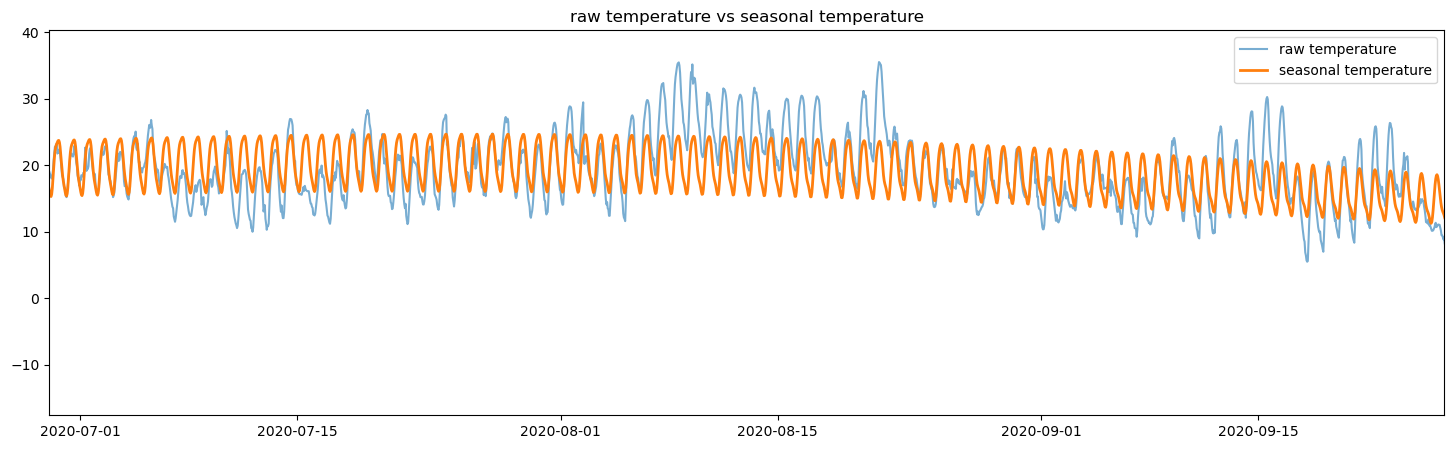

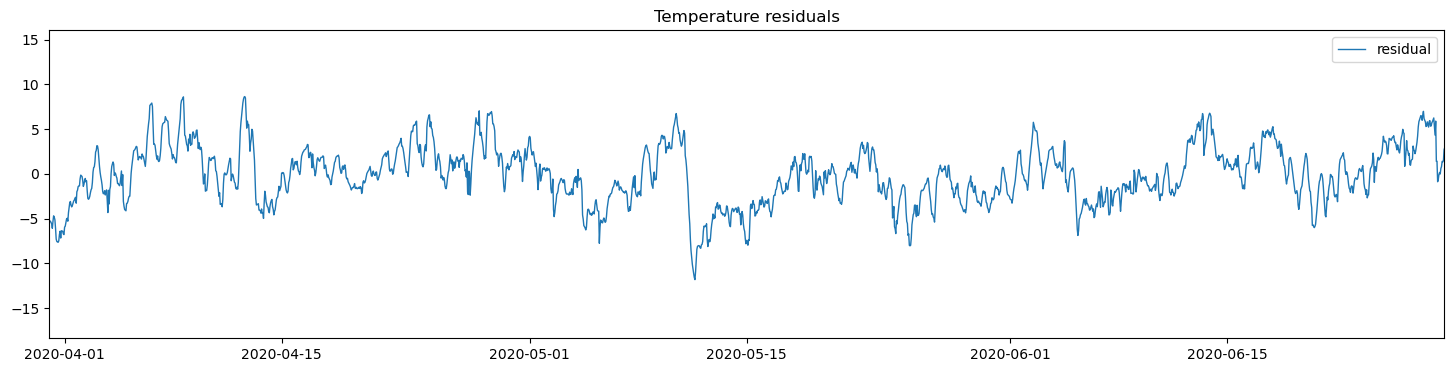

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))
plt.plot(temp.index, temp.values, alpha=0.6, label="raw temperature")
plt.plot(temp.index, temp_fit, linewidth=2, label="seasonal temperature")
plt.xlim(temp.index[24*30*6], temp.index[24*30*9])  
plt.legend()
plt.title("raw temperature vs seasonal temperature")
plt.show()

plt.figure(figsize=(18,4))
plt.plot(temp_resid.index, temp_resid.values, linewidth=1, label="residual")
plt.legend()
plt.xlim(temp.index[24*30*3], temp.index[24*30*6])  
plt.title("Temperature residuals")
plt.show()


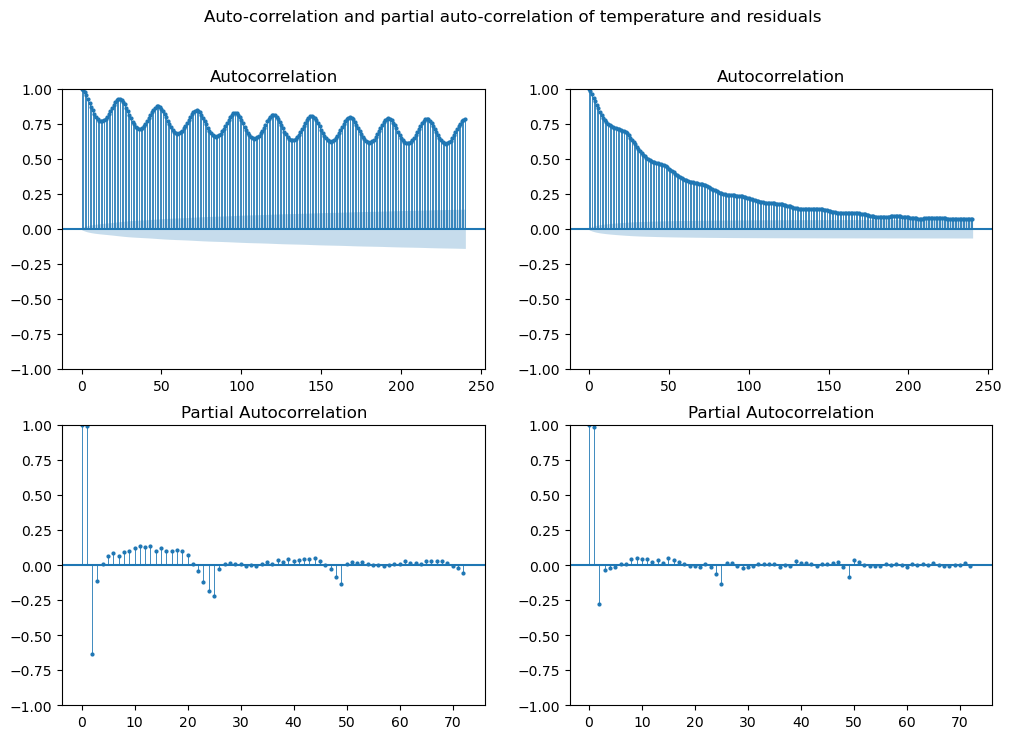

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(2,2, figsize=(12,8))
fig.suptitle('Auto-correlation and partial auto-correlation of temperature and residuals')
plot_acf(temp, lags=10*24, ax=axs[0,0], vlines_kwargs={"linewidth":0.6}, markersize=2)
plot_pacf(temp, lags=3*24, ax=axs[1,0], vlines_kwargs={"linewidth":0.6}, markersize=2)
plot_acf(temp_resid, lags=10*24, ax=axs[0,1], vlines_kwargs={"linewidth":0.6}, markersize=2)
plot_pacf(temp_resid, lags=3*24, ax=axs[1,1], vlines_kwargs={"linewidth":0.6}, markersize=2)
plt.show()

### Deseasonalise prices : Paraschiv's method

The spot price is decomposed into a deterministic seasonal component and a stochastic component:

$$
P_t = f_t + X_t
$$

where $f_t$ is the deterministic seasonality and $X_t$ the deseasonalized residual.

The deterministic component can be written as a trend plus seasonality:

$$
f_t = f_t^{trend} + f_t^{season}
$$

with linear trend

$$
f_t^{trend} = a^{trend} + b^{trend} t
$$

In the empirical implementation, the seasonal shape is constructed multiplicatively as:

$$
s_t = \bar P \, f2y_t \, f2d_t
$$

and the deseasonalized price is:

$$
X_t = P_t - s_t
$$

### Factor-to-year

Let $S_{day}(d)$ be the average spot price of day $d$. The factor-to-year is defined by:

$$
f2y_d
=
\frac{S_{day}(d)}
{\frac{1}{K(d)} \sum_{k \in year(d)} S_{day}(k)}
$$

where $K(d)$ is the number of days in the year containing day $d$.

It is modeled by the regression:

$$
f2y_d
=
\alpha_0
+
\sum_{i=1}^{6} b_i D_{d,i}
+
\sum_{i=1}^{12} c_i M_{d,i}
+
\sum_{i=1}^{3} d_i \, CDD_{d,i}
+
\sum_{i=1}^{3} e_i \, HDD_{d,i}
+
\varepsilon_d
$$

with

$$
CDD = \max(T - 18.3, 0)
$$

$$
HDD = \max(18.3 - T, 0)
$$

The daily factor is then converted to hourly frequency by:

$$
f2y_t = f2y_d \qquad \text{for all } t \in d
$$

### Factor-to-day

Let $S_{hour}(t)$ be the hourly spot price. The factor-to-day is defined by:

$$
f2d_t
=
\frac{S_{hour}(t)}
{\frac{1}{24}\sum_{k \in day(t)} S_{hour}(k)}
$$

Days are partitioned into 20 profile classes. For each class $c$, the intraday profile is estimated by:

$$
f2d_t
=
a_0^{(c)}
+
\sum_{i=1}^{23} b_i^{(c)} H_{t,i}
+
\varepsilon_t,
\qquad t \in c
$$

where $H_{t,i}$ are hour-of-day dummies.

### Final seasonal shape

The relative hourly seasonal weight is:

$$
sw_t = f2y_t \, f2d_t
$$

The deterministic seasonal component is then:

$$
s_t = \bar P \, sw_t = \bar P \, f2y_t \, f2d_t
$$

Finally, the deseasonalized price is:

$$
X_t = P_t - s_t
$$

In [8]:
import numpy as np
import pandas as pd

price = prices_df["price_eur_mwh"].copy().sort_index().asfreq("h").interpolate(method="linear")
day_mean = price.resample("D").mean()
day_mean_per_hour = day_mean.reindex(price.index.floor("D")).to_numpy(dtype=float)
f2d = (price.to_numpy(dtype=float) / day_mean_per_hour)

In [9]:
idx = price.index

dow = idx.dayofweek   
month = idx.month

profile_class = np.zeros(len(idx), dtype=int)

for i in range(len(idx)):

    m = month[i]
    d = dow[i]

    #weekdays (Mon-Fri)
    
    if d <= 4:
        profile_class[i] = m

    #saturady
    elif d == 5:

        if m in [1, 2, 12]:
            profile_class[i] = 13
        elif m in [3, 4, 5]:
            profile_class[i] = 14
        elif m in [6, 7, 8]:
            profile_class[i] = 15
        else:  # Sep-Oct-Nov
            profile_class[i] = 16

    #sunday
    elif d == 6:

        if m in [1, 2, 12]:
            profile_class[i] = 17
        elif m in [3, 4, 5]:
            profile_class[i] = 18
        elif m in [6, 7, 8]:
            profile_class[i] = 19
        else:  # Sep-Oct-Nov
            profile_class[i] = 20

hour_dummies = pd.get_dummies(idx.hour, drop_first=True).astype(float)
X = np.column_stack([np.ones(len(idx)), hour_dummies.to_numpy()])

f2d_hat = np.zeros(len(idx), dtype=float)
class_ids = np.unique(profile_class)

for class_id in class_ids:
    mask = (profile_class == class_id)
    X_class = X[mask]
    price_class = price[mask].to_numpy()
    
    coeffs, *_ = np.linalg.lstsq(X_class, price_class, rcond=None)
    predicted_prices = X_class @ coeffs
    
    mean_of_class_shape = np.mean(predicted_prices)
    if mean_of_class_shape != 0:
        f2d_hat[mask] = predicted_prices / mean_of_class_shape
    else:
        f2d_hat[mask] = 1.0

averageprice=price.mean()

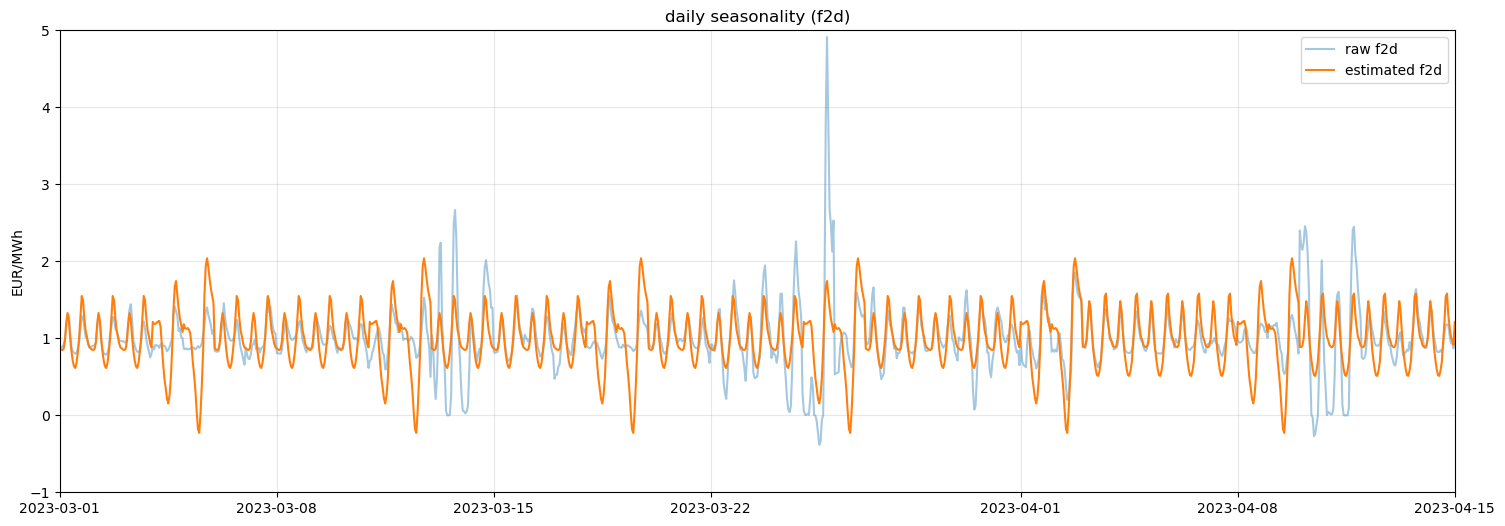

In [10]:
plt.figure(figsize=(18,6))
plt.plot(idx, f2d, alpha=0.4, label="raw f2d")
plt.plot(idx, f2d_hat, label="estimated f2d")

start_zoom = "2023-03-01"
end_zoom = "2023-04-15"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.ylim(-1,5)
plt.title("daily seasonality (f2d)")
plt.ylabel("EUR/MWh")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


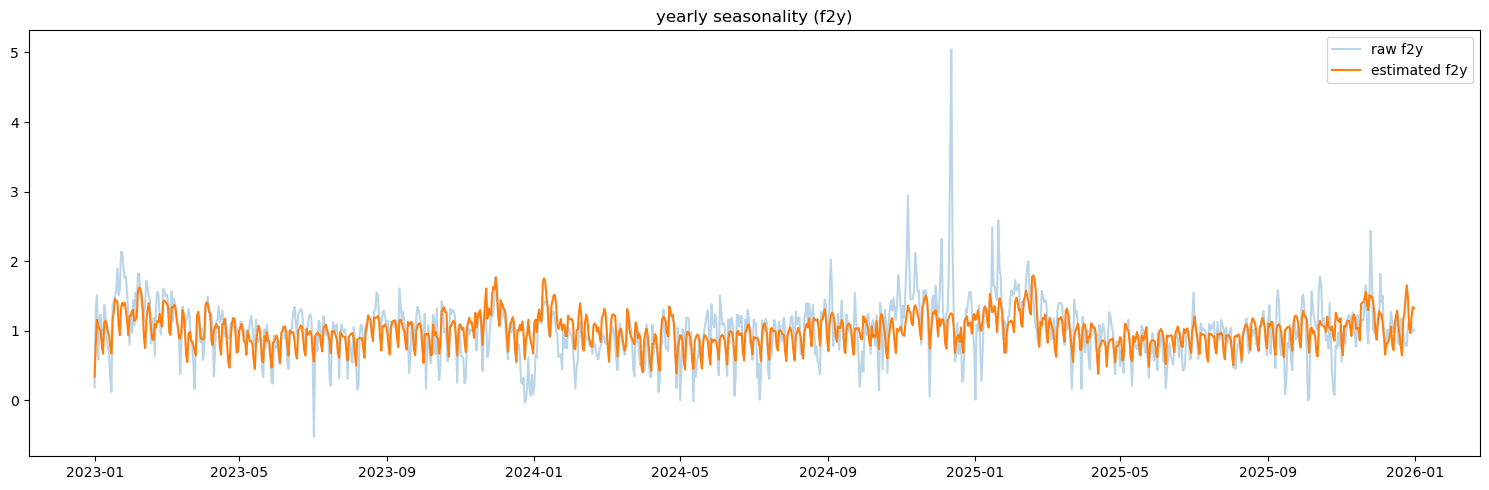

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

price = prices_df["price_eur_mwh"].copy().sort_index().asfreq("h").interpolate(method="linear").copy()

S_day = price.resample("D").mean()
temp_day = temp.resample("D").mean()

combined_base = (
    pd.concat(
        [S_day.rename("price_eur_mwh"), temp_day.rename("temperature_c")],
        axis=1,
        join="inner",
    )
    .dropna()
)

S_day = combined_base["price_eur_mwh"]
temp_day = combined_base["temperature_c"]

yearly_mean = S_day.groupby(S_day.index.year).transform("mean")
y = (S_day / yearly_mean).dropna()

X = pd.DataFrame(index=y.index)

# Daily dummies (Mon..Sat, Sunday is baseline)
day_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam"]
for d in range(6):
    X[day_labels[d]] = (X.index.dayofweek == d).astype(int)

# Monthly dummies 
for m in range(2, 13):
    if m != 8:
        X[f"Mois_{m}"] = (X.index.month == m).astype(int)

X["Aout_Deb"] = ((X.index.month == 8) & (X.index.day <= 15)).astype(int)
X["Aout_Fin"] = ((X.index.month == 8) & (X.index.day > 15)).astype(int)

t = temp_day.reindex(y.index)
X["Chauffage_HDD"] = (15 - t).clip(lower=0)
X["Clim_CDD"] = (t - 15).clip(lower=0)

X = sm.add_constant(X)

df_model = pd.concat([y.rename("y"), X], axis=1).dropna()
y2 = df_model["y"]
X2 = df_model.drop(columns=["y"])

model_f2y = sm.OLS(y2, X2).fit()
f2y_d_hat = model_f2y.fittedvalues

plt.figure(figsize=(15, 5))
plt.plot(y2.index, y2, label="raw f2y", alpha=0.3)
plt.plot(f2y_d_hat.index, f2y_d_hat, label="estimated f2y")
plt.title("yearly seasonality (f2y)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
#turn daily f2y into hourly f2y
f2y_t_hat = f2y_d_hat.reindex(price.index.floor("D")).to_numpy()
f2y_t_hat = pd.Series(f2y_t_hat, index=price.index, name="f2y_t_hat")

#compute seasonality  s=f2y*f2d*average price
sw_t = f2y_t_hat * f2d_hat
yearly_avg = np.mean(price.values)
price_fit = sw_t * yearly_avg

price_resid = price.values-price_fit
price_resid = price_resid.ffill()

#compute seasonality  s=f2y*f2d*average price
sw_t = f2y_t_hat * f2d_hat

yearly_avg = np.mean(price.values)
price_fit = sw_t * yearly_avg

price_resid = price.values-price_fit
price_resid = price_resid.ffill()

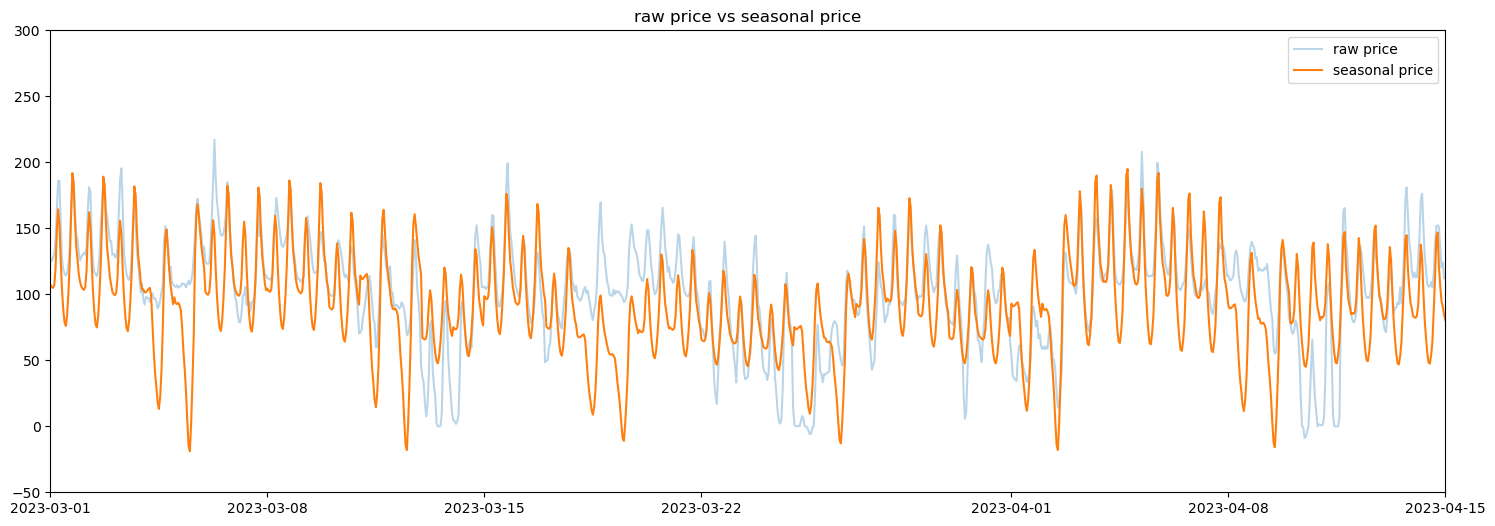

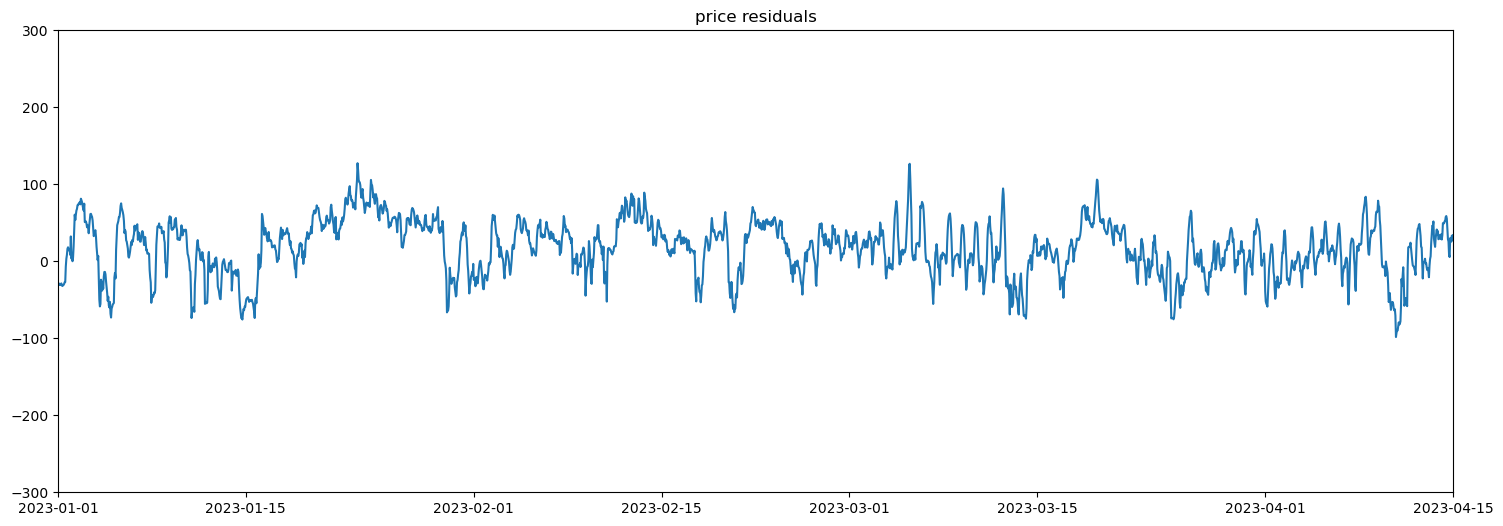

In [21]:
plt.figure(figsize=(18, 6))
plt.plot(price.index, price, alpha=0.3, label="raw price")

plt.plot(price.index, price_fit, label="seasonal price")
start_zoom = "2023-03-01"
end_zoom = "2023-04-15"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.ylim(-50, 300)
plt.title("raw price vs seasonal price")
plt.legend()


plt.figure(figsize=(18,6))
plt.plot(idx, price_resid)
start_zoom = "2023-01-01"
end_zoom = "2023-04-15"
plt.xlim(pd.Timestamp(start_zoom), pd.Timestamp(end_zoom))
plt.title("price residuals")
plt.ylim(-300, 300)
plt.show()


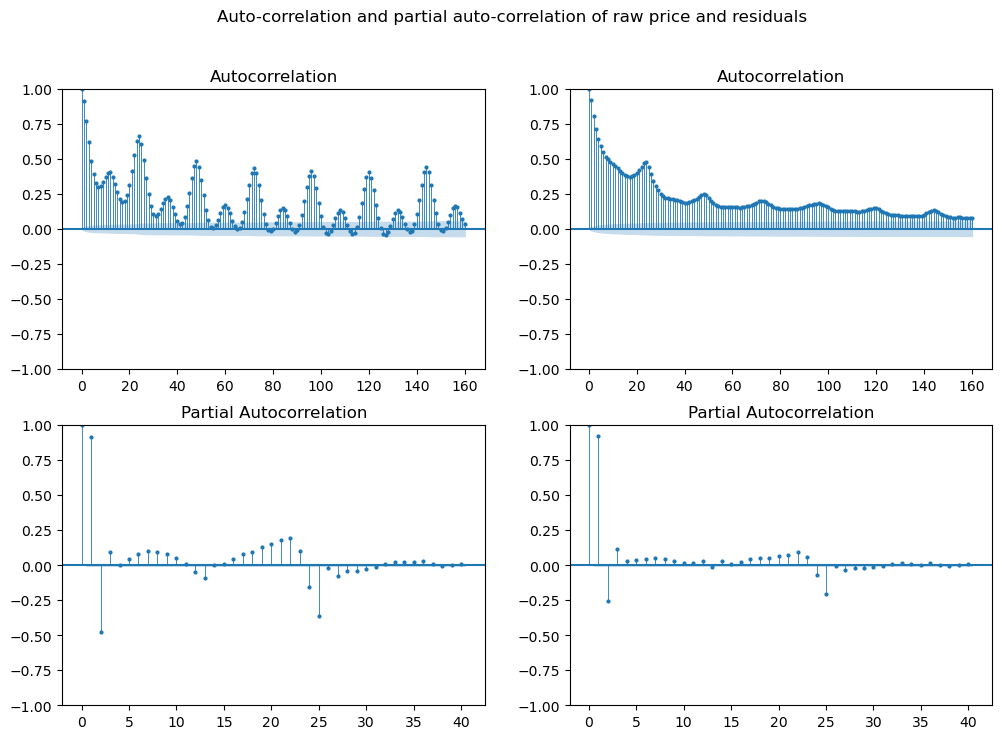

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(2,2, figsize=(12,8))
fig.suptitle('Auto-correlation and partial auto-correlation of raw price and residuals')
plot_acf(price, lags=160, ax=axs[0,0], vlines_kwargs={"linewidth":0.6}, markersize=2)
plot_pacf(price, lags=40, ax=axs[1,0], vlines_kwargs={"linewidth":0.6}, markersize=2)
plot_acf(price_resid, lags=160, ax=axs[0,1],vlines_kwargs={"linewidth":0.6}, markersize=2)
plot_pacf(price_resid, lags=40, ax=axs[1,1],vlines_kwargs={"linewidth":0.6}, markersize=2)
plt.show()

In [15]:
temp_resid_path = DATA_DIR / "temp_resid.csv"
temp_resid.to_csv(temp_resid_path)
temp_resid.head()

price_resid_path = DATA_DIR / "price_resid.csv" #cree emplacement
price_resid.to_csv(price_resid_path) #écrit dans le fichier
price_resid_path #affiche chemin fichier

WindowsPath('c:/Users/gabri/Documents/quant-projects/carma-research/data/price_resid.csv')